# Shopify Sales Analysis: Investigating a Major Sales Shift

#### Identified and quantified a persistent shift in daily sales using time-series analysis with regression, statistical testing (t-test), and visualization. Python, Pandas, SciPy, Matplotlib.

## Business Objective

The objective of this analysis is to identify and understand significant changes in Shopify sales performance over time and translate those findings into actionable business insights.

Specifically, the analysis aims to:

* Identify significant and persistent changes in daily sales.
* Quantify the magnitude and timing of these changes.
* Determine whether the changes are concentrated within specific customer segments.
* Investigate potential business drivers behind major sales shifts.
* Identify what additional data and causal analysis would be needed to determine whether specific business interventions contributed to the observed changes.

Ultimately, the goal is to provide a data-driven framework for understanding changes in sales performance and identifying opportunities to replicate or scale effective business actions.


## Analysis 1 — Exploratory Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# get all filenames under the data directory 
all_data = [pd.read_csv(filename) for filename in glob.glob('sales_data_analysis_datasets/*.csv')]

# check the list size to understand how many files will be read
# should be equal to 50
print(len(all_data))

#  create the dataset using all files under the data directory
working_df = pd.concat(all_data, axis=0)

df = working_df.copy()

df.head()

50


,sale_time,purchaser_gender
0,2013-01-07 02:14:07,female
1,2013-01-07 02:57:53,male
2,2013-01-07 02:59:49,female
3,2013-01-07 03:02:53,male
4,2013-01-07 03:27:36,female


In [2]:
# Number of rows and columns
df.shape

(204329, 2)

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 204329 entries, 0 to 4974
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   sale_time         204329 non-null  object
 1   purchaser_gender  204329 non-null  object
dtypes: object(2)
memory usage: 4.7+ MB


In [4]:
df['sale_time'] = pd.to_datetime(df['sale_time'])

In [5]:
df[df.duplicated()]

,sale_time,purchaser_gender
233,2013-01-07 12:22:47,female
351,2013-01-07 15:27:13,female
1322,2013-01-09 15:28:25,female
1594,2013-01-10 08:35:47,female
2052,2013-01-11 05:07:40,female
...,...,...
3958,2013-08-17 14:38:24,female
4234,2013-08-17 21:00:59,female
4571,2013-08-18 12:03:28,female
4633,2013-08-18 13:30:05,male


In [6]:
df = df.drop_duplicates()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 203821 entries, 0 to 4974
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   sale_time         203821 non-null  datetime64[ns]
 1   purchaser_gender  203821 non-null  object        
dtypes: datetime64[ns](1), object(1)
memory usage: 4.7+ MB


In [8]:
df.describe()

,sale_time
count,203821
mean,2013-04-08 09:48:58.813542144
min,2012-10-01 01:42:22
25%,2013-01-10 13:38:23
50%,2013-04-21 10:33:16
75%,2013-07-05 12:13:15
max,2013-09-15 23:48:47


## Analysis 2 — Overall Sales Trend Visualization

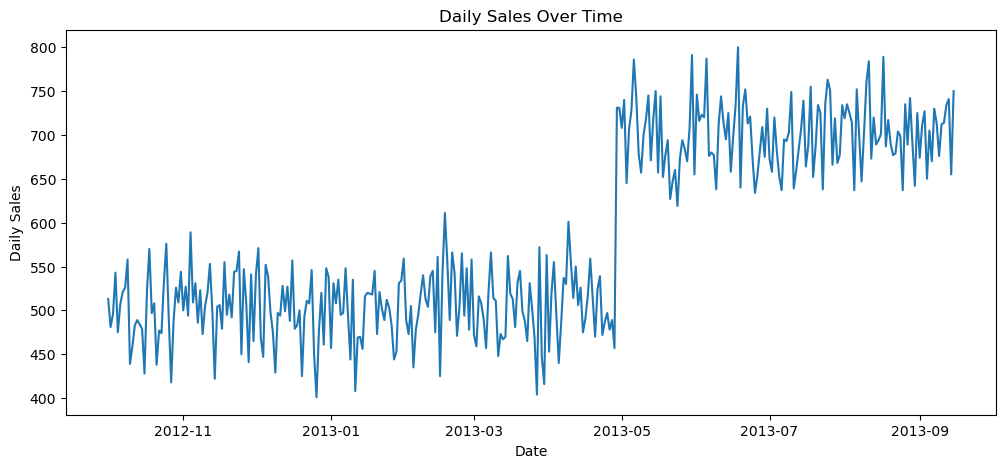

In [9]:
df['sale_date'] = df['sale_time'].dt.date

daily_sales = (
    df
    .groupby('sale_date', as_index=False)
    .agg(
        daily_sales=('purchaser_gender', 'count')
    )
)

plt.figure(figsize=(12, 5))

plt.plot(daily_sales['sale_date'], daily_sales['daily_sales'])

plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.title('Daily Sales Over Time')

plt.show()

### Business Interpretation

The daily sales trend reveals a sharp increase in sales, suggesting that a meaningful shift may have occurred during the period.

The next step is to identify the specific date associated with the largest day-over-day increase so that we can investigate what may have caused the spike and identify potential drivers of the change.

## Analysis 3 — Detecting the Date of the Sudden Change

In [10]:
# Find the largest day-over-day change
daily_sales['sales_change'] = daily_sales['daily_sales'].diff()

change_point = daily_sales[
    daily_sales['sales_change'] == daily_sales['sales_change'].max()
]

print('Largest day-over-day change:')
print(change_point)

Largest day-over-day change:
      sale_date  daily_sales  sales_change
210  2013-04-29          731         274.0


### Business Interpretation

The largest positive day-over-day change occurred on April 29, 2013.

Next, we will use a Welch's two-sample t-test to determine whether the change represents a statistically significant shift in the overall level of daily sales. The reason is that a large change in sales does not necessarily mean that the underlying sales level truly changed, sometimes it could be just random variations.

*Note: A Welch's t-test is used to compare the means of two independent groups. It assumes that the observations within each group are independent and that the outcome is approximately normally distributed, particularly when the sample size is small.*

## Analysis 4 — Testing the Statistical Significance of the Change And Quantifying the Business Impact

In [11]:
from scipy import stats

# Split sales into before and after the change
change_date = change_point['sale_date'].max()

before = daily_sales[
    daily_sales['sale_date'] < change_date
]['daily_sales']

after = daily_sales[
    daily_sales['sale_date'] >= change_date
]['daily_sales']

# Compare average daily sales
before_mean = before.mean().round(0)
after_mean = after.mean().round(0)

change_mean = after_mean - before_mean

percent_change = (
    (after_mean - before_mean)
    / before_mean
    * 100
).round(0)

# Statistical test
t_stat, p_value = stats.ttest_ind(
    before,
    after,
    equal_var=False
)

# Results
print('Change date:', change_date)
print('Average daily sales before:', before_mean)
print('Average daily sales after:', after_mean)
print('Average sales change:', change_mean)
print('Percentage change:', percent_change)
print('t-statistic:', t_stat)
print('p-value:', p_value)

Change date: 2013-04-29
Average daily sales before: 503.0
Average daily sales after: 701.0
Average sales change: 198.0
Percentage change: 39.0
t-statistic: -46.064861938376914
p-value: 1.748078387613175e-138


### Business Interpretation

The p-value is far below the 0.05 significance threshold. Therefore, we reject the null hypothesis that the two periods have the same average daily sales. This provides strong statistical evidence that **average daily sales differed between the periods before and after April 29, 2013**.

Average daily sales increased from approximately **503** before the change to **701** after the change. This represents an absolute increase of approximately **198 sales per day**, or a **39% increase**.

Next, we investigate whether the sales increase is persistent or just a temporary spike.

This distinction is important for the business. A temporary spike may have been caused by a short-term event such as a promotion, while a sustained increase could indicate a longer-lasting change in customer behavior or business performance.

We use a 7-day rolling average to smooth out daily fluctuations and evaluate whether the higher sales level continued after April 29.


## Analysis 6 — Was the Change Persistent or Temporary?

In [12]:
daily_sales['rolling_7_day_sales'] = (
    daily_sales['daily_sales']
    .rolling(7)
    .mean()
)

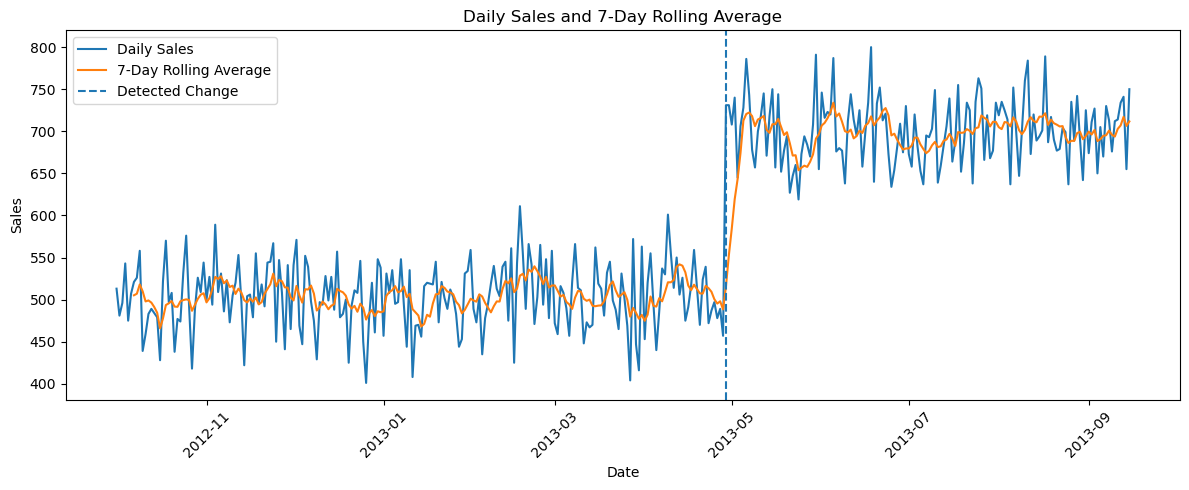

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales['sale_date'],
    daily_sales['daily_sales'],
    label='Daily Sales'
)

plt.plot(
    daily_sales['sale_date'],
    daily_sales['rolling_7_day_sales'],
    label='7-Day Rolling Average'
)

plt.axvline(
    change_date,
    linestyle='--',
    label='Detected Change'
)

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Daily Sales and 7-Day Rolling Average')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Business Interpretation

The 7-day rolling average remains substantially higher after the detected date, suggesting that the increase was persistent rather than simply a one-day spike. This indicates that the sales increase may reflect a sustained change in business or product performance, rather than a temporary fluctuation.

Next, we investigate how the sales increase differed by gender. Understanding which segment contributed to the change can help the business determine whether a particular customer group may have responded differently to whatever happened around April 29.

## Analysis 7A — Segmentation Analysis by Gender

In [14]:
daily_sales_by_gender = (
    df
    .groupby(['sale_date', 'purchaser_gender'], as_index=False)
    .agg(
        sales_count=('sale_time', 'count')
    )
)

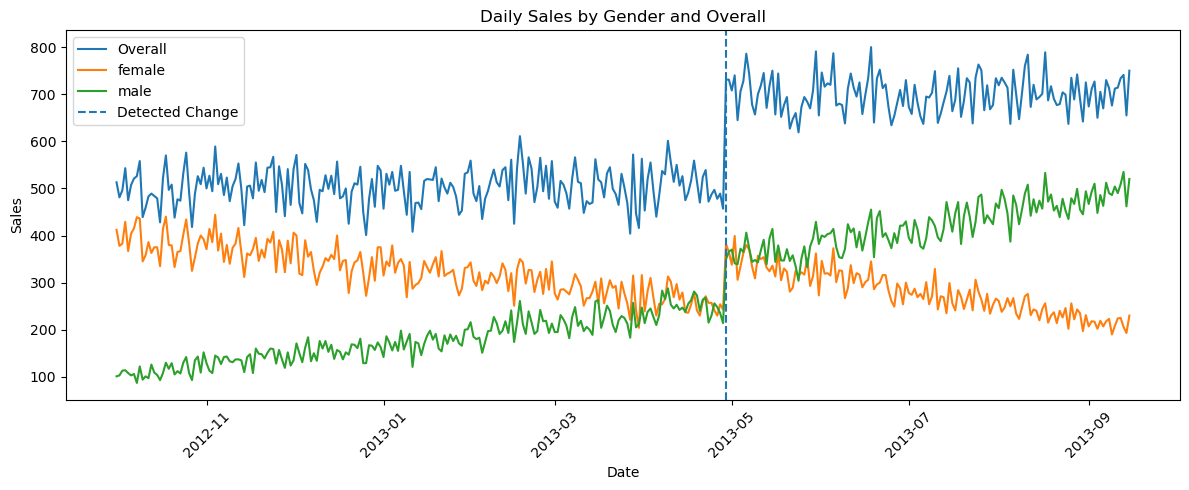

In [15]:
plt.figure(figsize=(12, 5))

# Overall sales
plt.plot(
    daily_sales['sale_date'],
    daily_sales['daily_sales'],
    label='Overall'
)

# Male and Female sales
for gender in daily_sales_by_gender['purchaser_gender'].unique():
    gender_data = daily_sales_by_gender[
        daily_sales_by_gender['purchaser_gender'] == gender
    ]

    plt.plot(
        gender_data['sale_date'],
        gender_data['sales_count'],
        label=gender
    )

plt.axvline(
    change_date,
    linestyle='--',
    label='Detected Change'
)

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Daily Sales by Gender and Overall')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Business Interpretation

Over the entire period, male sales have been trending upward, while female sales have been trending downward. Around the change date, both groups show a similar increase, suggesting that the detected shift affected both segments. 

Next, we quantify the change in daily sales for each gender segment to assess the magnitude of the business impact and determine which segment contributed most to the overall sales shift.

## Analysis 7B — Quantifying the Gender-Level Change

In [16]:
average_daily_sales_by_gender_before = (
    daily_sales_by_gender[
        daily_sales_by_gender['sale_date'] < change_date
    ]
    .groupby('purchaser_gender')
    .agg(
        sales_count=('sales_count', 'mean')
    )
)

average_daily_sales_by_gender_after = (
    daily_sales_by_gender[
        daily_sales_by_gender['sale_date'] >= change_date
    ]
    .groupby('purchaser_gender')
    .agg(
        sales_count=('sales_count', 'mean')
    )
)

average_daily_sales_percent_change = 100 * (average_daily_sales_by_gender_after - average_daily_sales_by_gender_before) / average_daily_sales_by_gender_after

print('Average daily sales by gender before:')
print(np.floor(average_daily_sales_by_gender_before))

print()

print('Average daily sales by gender after:')
print(np.floor(average_daily_sales_by_gender_after))

print()

print('Average daily percentage change by gender:')
print(average_daily_sales_percent_change.round())

Average daily sales by gender before:
                  sales_count
purchaser_gender             
female                  325.0
male                    177.0

Average daily sales by gender after:
                  sales_count
purchaser_gender             
female                  279.0
male                    421.0

Average daily percentage change by gender:
                  sales_count
purchaser_gender             
female                  -17.0
male                     58.0


### Business Interpretation

The gender-level analysis shows that the sales shift was primarily associated with male purchasers. Average daily male sales increased from **177 to 421**, representing a **58% increase** after the change point. In contrast, average daily female sales decreased from **325 to 279**, representing a **17% decrease**.

This indicates that the overall increase in daily sales was driven primarily by the male segment, while female sales declined during the same period.

However, this analysis does not indicate that the increase in male sales was the reason for the overall increase in sales. Instead, it identifies a customer segment that experienced a particularly large change and provides a direction for further investigation. For example, demographic characteristics and order history data for male purchasers could help identify potential drivers of the overall sales increase.

## Analysis 9 — Interrupted Time-Series Analysis

The earlier analysis showed that daily sales changed substantially around April 29, 2013. I used a Welch's t-test to confirm that average daily sales before and after this date were statistically different, but this comparison does not account for the underlying time trend. Because April 29 occurs in the middle of an ongoing sales trajectory, I want to determine whether the level or slope of that trend changed around the detected date.

An interrupted time-series model allows me to estimate the change in sales around April 29 while accounting for the existing trend over time. This helps answer a more specific question:

**After accounting for the underlying sales trend, was there still a meaningful shift in sales around April 29?**


In [18]:
# Create a time index
daily_sales['time'] = range(len(daily_sales))

# Create an indicator for the period after the change
daily_sales['post_change'] = (
    daily_sales['sale_date'] >= change_date
).astype(int)

# Create an interaction term to capture a change in slope
daily_sales['time_after_change'] = (
    daily_sales['time'] * daily_sales['post_change']
)

# Run the interrupted time-series regression
import statsmodels.api as sm

X = daily_sales[
    ['time', 'post_change', 'time_after_change']
]

X = sm.add_constant(X)

y = daily_sales['daily_sales']

its_model = sm.OLS(y, X).fit()

print(its_model.summary())

                            OLS Regression Results                            
Dep. Variable:            daily_sales   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     699.1
Date:                Sat, 19 Sep 2026   Prob (F-statistic):          1.89e-146
Time:                        08:59:11   Log-Likelihood:                -1781.7
No. Observations:                 350   AIC:                             3571.
Df Residuals:                     346   BIC:                             3587.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               501.1740      5.43

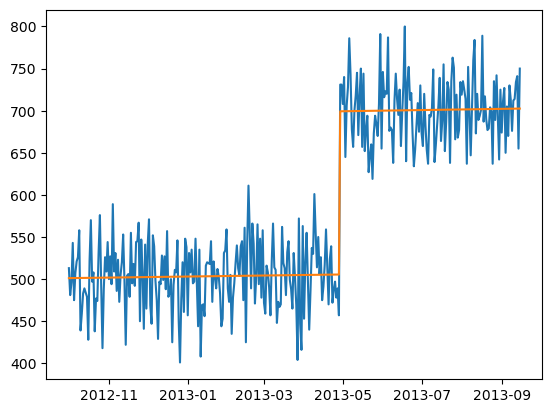

In [20]:
daily_sales['predicted_sales'] = its_model.predict(X)

plt.plot(
    daily_sales['sale_date'],
    daily_sales['daily_sales'],
    label='Actual Sales'
)

plt.plot(
    daily_sales['sale_date'],
    daily_sales['predicted_sales'],
    label='ITS Model'
)

In [21]:
import statsmodels.api as sm

# Create a time index centered on the change date
change_index = daily_sales.index[
    daily_sales['sale_date'] == change_date
][0]

daily_sales['time'] = daily_sales.index - change_index

# Create an indicator for the period after the change
daily_sales['post_change'] = (
    daily_sales['sale_date'] >= change_date
).astype(int)

# Create an interaction term to capture a change in slope
daily_sales['time_after_change'] = (
    daily_sales['time'] * daily_sales['post_change']
)

# Define predictors and outcome
X = daily_sales[
    ['time', 'post_change', 'time_after_change']
]

X = sm.add_constant(X)

y = daily_sales['daily_sales']

# Fit the ITS regression
its_model = sm.OLS(y, X).fit()

print(its_model.summary())

                            OLS Regression Results                            
Dep. Variable:            daily_sales   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     699.1
Date:                Sat, 19 Sep 2026   Prob (F-statistic):          1.89e-146
Time:                        09:04:21   Log-Likelihood:                -1781.7
No. Observations:                 350   AIC:                             3571.
Df Residuals:                     346   BIC:                             3587.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               505.4751      5.47

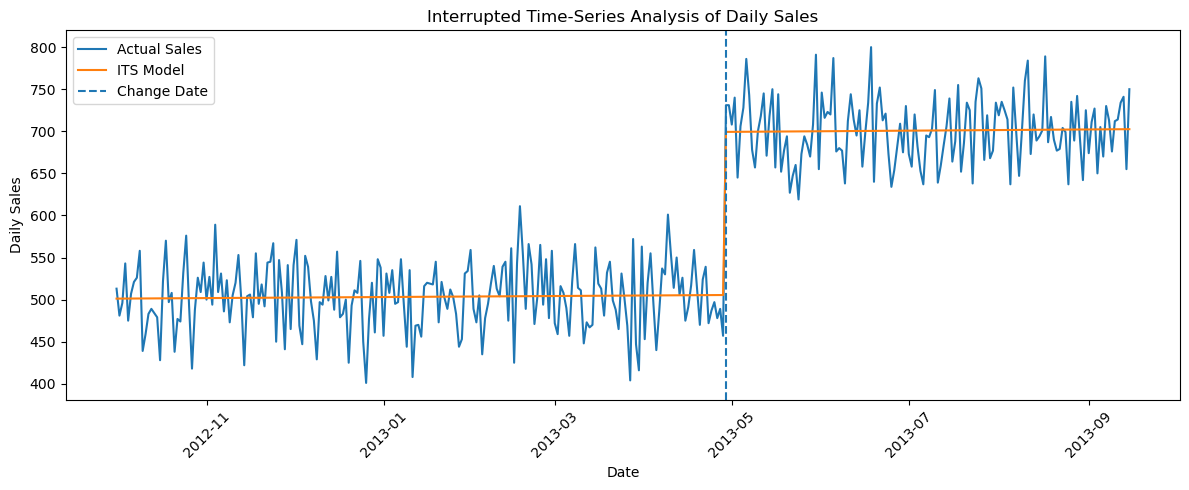

In [22]:
# Generate predicted sales
daily_sales['predicted_sales'] = its_model.predict(X)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales['sale_date'],
    daily_sales['daily_sales'],
    label='Actual Sales'
)

plt.plot(
    daily_sales['sale_date'],
    daily_sales['predicted_sales'],
    label='ITS Model'
)

plt.axvline(
    change_date,
    linestyle='--',
    label='Change Date'
)

plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.title('Interrupted Time-Series Analysis of Daily Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Business Interpretation

The interrupted time-series analysis indicates that the sales increase around April 29 was primarily an **immediate level shift rather than a change in the underlying sales trend**.

At the change point, the model estimates an immediate increase of approximately **194 daily sales** (95% CI: 177–211, p < 0.001). This provides strong statistical evidence of a substantial shift to a higher sales level around April 29.

In contrast, the estimated pre-change slope was not statistically significant (p = 0.649), and there was no statistically significant change in slope after April 29 (p = 0.977). This suggests that sales did not begin growing at a significantly faster rate after the change point; instead, sales moved to a higher level and remained elevated.

The model explains approximately **85.8% of the variation in daily sales**, indicating a strong fit to the observed data. However, the ITS analysis identifies a significant change around April 29 but does not by itself establish that a specific business action caused the increase.

### Next Steps

The next step would be to connect this time-series finding with business-event data and segment-level analysis to determine what may have contributed to the sustained increase.

To determine whether a specific intervention caused the increase, I would need additional data and an appropriate causal design. For example, a randomized rollout could support an **A/B test**, while a comparable untreated market or phased rollout could potentially support **Difference-in-Differences**.

Ultimately, this would move the analysis from identifying what changed and what was associated with the change toward understanding what caused the change and which business actions could be replicated or scaled to support future sales growth.


### Project Limitations

* The dataset only contains transaction-level timestamps and purchaser gender information.
* Because the underlying cause of the April 29 change is unknown, the analysis cannot attribute the increase to a specific business intervention.
* The pre/post comparison and statistical testing establish a difference in sales levels but do not establish causality.
* The interrupted time-series model identifies a level shift around the change point, but causal interpretation would require stronger assumptions and additional comparison data.
* The dataset covers approximately one year, limiting the ability to assess longer-term seasonal patterns.
